# Tech Challenge - Fase 2

## Classificação da Qualidade de Vinhos utilizando Machine Learning

**Aluno:** Gabriel Cristiano dos Santos

**RM:** 373684

**Curso:** Data Analytics - FIAP

# 1. Objetivo

O objetivo deste projeto é desenvolver modelos de Machine Learning capazes de classificar vinhos em duas categorias: Alta Qualidade e Baixa/Média Qualidade, utilizando características físico-químicas presentes na base de dados Wine Quality. Para isso, foram comparados dois algoritmos de classificação supervisionada: Regressão Logística e Random Forest.

In [57]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [58]:
import os

os.listdir()

['.config', 'WineQT.csv', 'sample_data']

In [59]:
df = pd.read_csv("WineQT.csv")

# 2. Conhecendo os Dados

Nesta etapa foi realizada a leitura da base de dados, bem como a verificação de sua estrutura, estatísticas descritivas e identificação de valores ausentes.

In [60]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [62]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [63]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Análise

A base de dados possui 1.143 registros e 13 variáveis. Não foram identificados valores ausentes, indicando boa qualidade dos dados para aplicação dos modelos de Machine Learning.

# 3. Preparação dos Dados

A variável "quality" foi transformada em uma variável binária, conforme solicitado pelo desafio.

- 0 → Baixa/Média Qualidade
- 1 → Alta Qualidade

In [64]:
df["quality"] = (df["quality"] >= 7).astype(int)

In [65]:
df["quality"].value_counts()

,count
quality,
0,984
1,159


In [66]:
df = df.drop("Id", axis=1)

In [67]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


# 4. Análise Exploratória dos Dados (EDA)

Nesta etapa foram analisadas as distribuições das variáveis, correlações e presença de outliers para compreender melhor o comportamento dos dados.

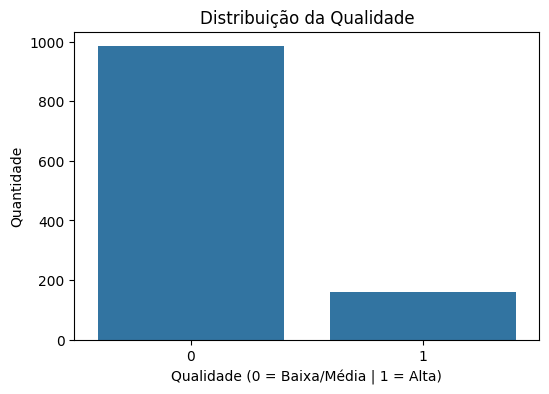

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df)

plt.title("Distribuição da Qualidade")
plt.xlabel("Qualidade (0 = Baixa/Média | 1 = Alta)")
plt.ylabel("Quantidade")

plt.show()

### Interpretação

Observa-se predominância de vinhos classificados como baixa/média qualidade, indicando desbalanceamento entre as classes.

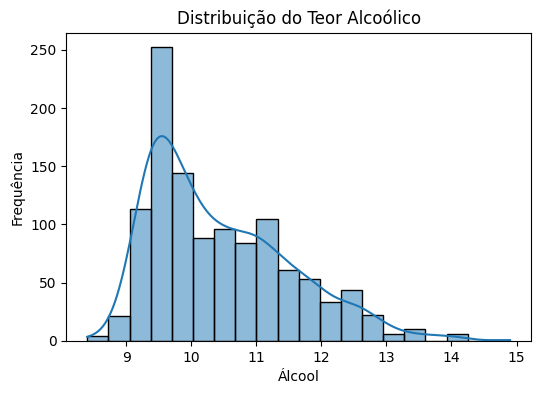

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df["alcohol"], bins=20, kde=True)

plt.title("Distribuição do Teor Alcoólico")
plt.xlabel("Álcool")
plt.ylabel("Frequência")

plt.show()

### Interpretação

O teor alcoólico apresenta distribuição aproximadamente contínua, com concentração entre 9% e 11%.

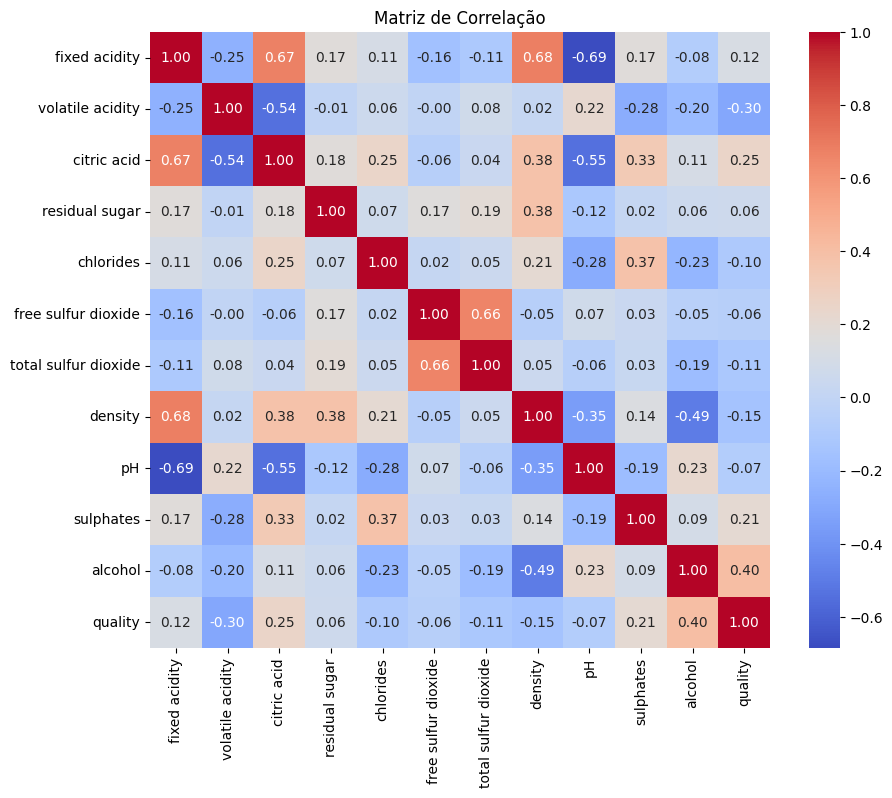

In [70]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()

### Interpretação

As variáveis Alcohol e Sulphates apresentaram correlação positiva com a qualidade, enquanto Volatile Acidity apresentou correlação negativa.

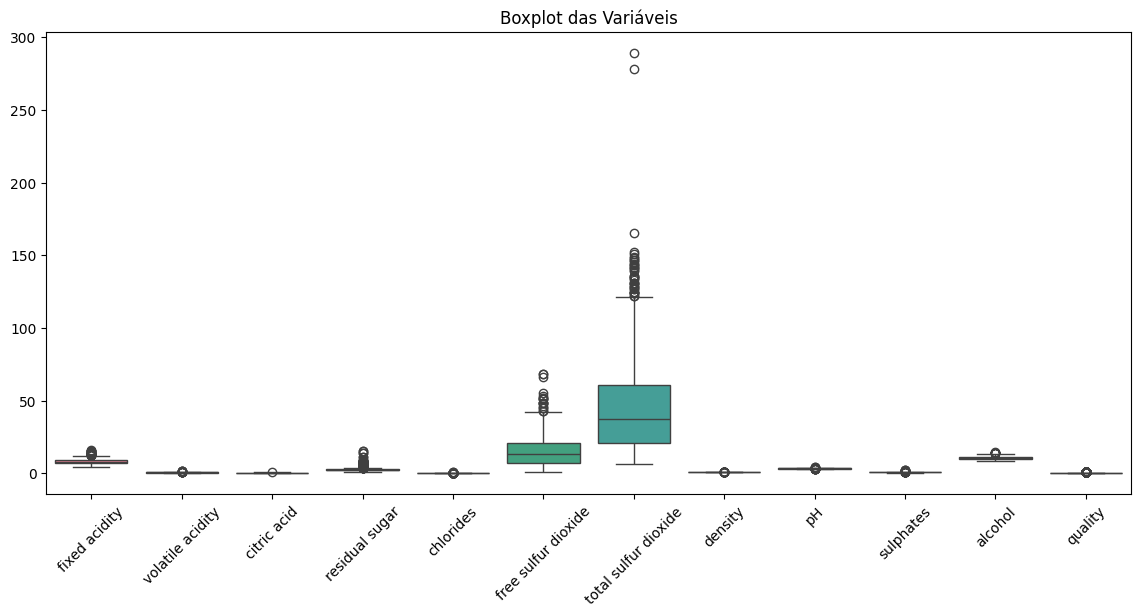

In [71]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Boxplot das Variáveis")

plt.show()

### Interpretação

Foram observados alguns outliers, porém eles foram mantidos na análise por não comprometerem o treinamento dos modelos.

# 5. Modelagem

In [72]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
modelo_lr = LogisticRegression()

modelo_lr.fit(X_train_scaled, y_train)

pred_lr = modelo_lr.predict(X_test_scaled)

In [76]:
print("Acurácia:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Acurácia: 0.9082969432314411
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229



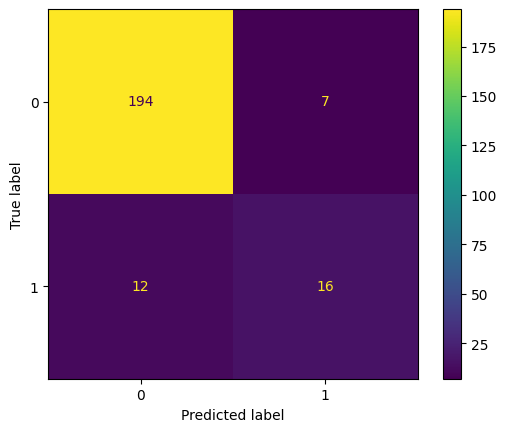

In [77]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)

plt.show()

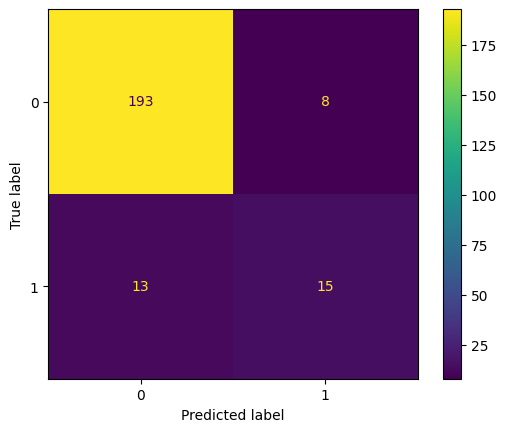

In [78]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr)

plt.show()

A Regressão Logística apresentou aproximadamente 91% de acurácia, demonstrando bom desempenho na classificação dos vinhos.

In [79]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

In [80]:
print("Acurácia:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Acurácia: 0.9170305676855895
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       201
           1       0.70      0.57      0.63        28

    accuracy                           0.92       229
   macro avg       0.82      0.77      0.79       229
weighted avg       0.91      0.92      0.91       229



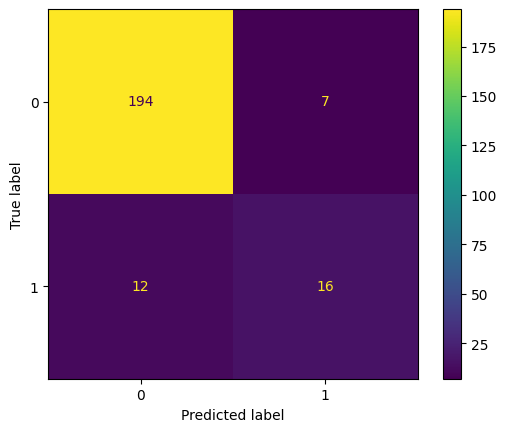

In [81]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)

plt.show()

### Avaliação do Random Forest

O Random Forest apresentou aproximadamente 92% de acurácia, superando a Regressão Logística e demonstrando melhor capacidade de classificação.

# 6. Conclusão

Os resultados obtidos indicam que o algoritmo Random Forest foi o modelo mais eficiente para o conjunto de dados analisado, apresentando maior capacidade de classificação quando comparado à Regressão Logística. Dessa forma, ele é o modelo recomendado para este problema de negócio.